# Country Development Intelligence System

This notebook applies unsupervised machine learning techniques to analyze socio-economic and health indicators of 167 countries. The objective is to group countries with similar development patterns using clustering algorithms and identify regions that may require focused developmental support.

## Goals

- Load and inspect the dataset
- Perform data cleaning and preprocessing
- Apply feature scaling
- Reduce dimensions using PCA
- Find optimal clusters using K-Means
- Detect outliers using DBSCAN
- Visualize country segments
- Generate country-level development insights

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub

/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv
/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/data-dictionary.csv


# Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# Load Dataset

In [3]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    print("FOLDER:", dirname)
    for filename in filenames:
        print("   ", filename)

FOLDER: /kaggle/input
FOLDER: /kaggle/input/datasets
FOLDER: /kaggle/input/datasets/rohan0301
FOLDER: /kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data
    Country-data.csv
    data-dictionary.csv


In [4]:
import pandas as pd

df = pd.read_csv(
    "/kaggle/input/datasets/rohan0301/unsupervised-learning-on-country-data/Country-data.csv"
)

print(df.shape)
df.head()

(167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


# Dataset Information

In [5]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


# Missing Values

In [6]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

# Duplicate Values

In [7]:
df.duplicated().sum()

np.int64(0)

# Country Column

In [8]:
countries = df['country']
df = df.drop('country', axis=1)

In [9]:
print(df.columns)

Index(['child_mort', 'exports', 'health', 'imports', 'income', 'inflation',
       'life_expec', 'total_fer', 'gdpp'],
      dtype='object')


# Correlation Heatmap

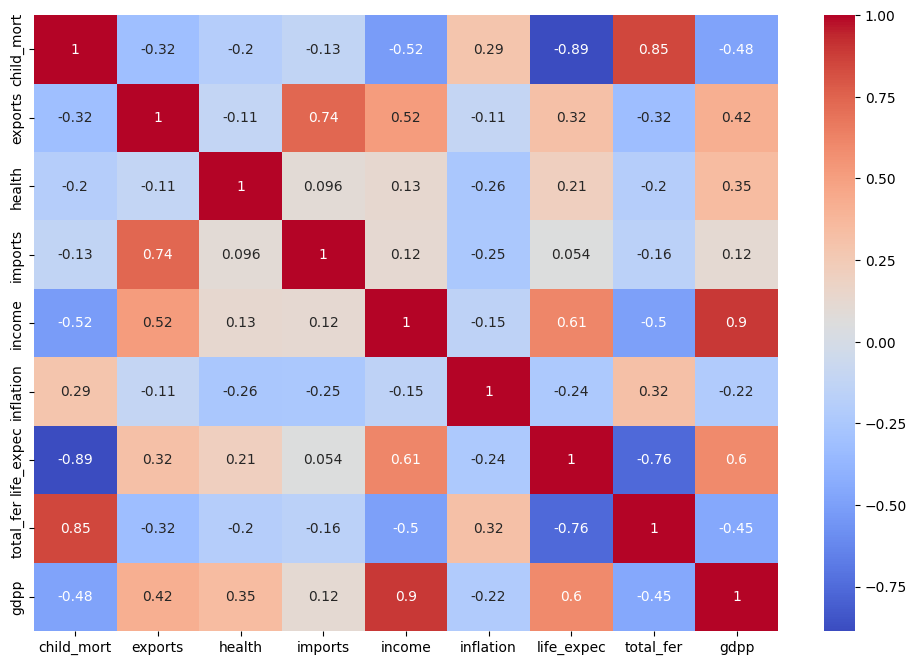

In [10]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.show()

# Feature Scaling

In [11]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=df.columns
)

scaled_df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,1.291532,-1.138280,0.279088,-0.082455,-0.808245,0.157336,-1.619092,1.902882,-0.679180
1,-0.538949,-0.479658,-0.097016,0.070837,-0.375369,-0.312347,0.647866,-0.859973,-0.485623
2,-0.272833,-0.099122,-0.966073,-0.641762,-0.220844,0.789274,0.670423,-0.038404,-0.465376
3,2.007808,0.775381,-1.448071,-0.165315,-0.585043,1.387054,-1.179234,2.128151,-0.516268
4,-0.695634,0.160668,-0.286894,0.497568,0.101732,-0.601749,0.704258,-0.541946,-0.041817


# PCA

In [12]:
pca = PCA()

pca.fit(scaled_df)

PCA()

## Explained Variance

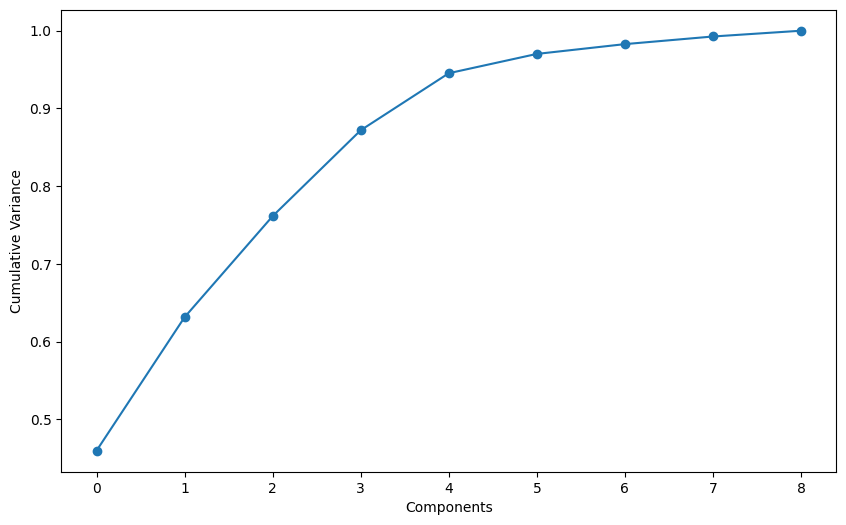

In [13]:
plt.figure(figsize=(10,6))

plt.plot(
    np.cumsum(
        pca.explained_variance_ratio_
    ),
    marker='o'
)

plt.xlabel("Components")
plt.ylabel("Cumulative Variance")

plt.show()

## Choose Components

In [14]:
pca = PCA(n_components=3)

pca_data = pca.fit_transform(scaled_df)

pca_df = pd.DataFrame(
    pca_data,
    columns=['PC1','PC2','PC3']
)

pca_df.head()

,PC1,PC2,PC3
0,-2.913025,0.095621,-0.718118
1,0.429911,-0.588156,-0.333486
2,-0.285225,-0.455174,1.221505
3,-2.932423,1.695555,1.525044
4,1.033576,0.136659,-0.225721


# Elbow Method

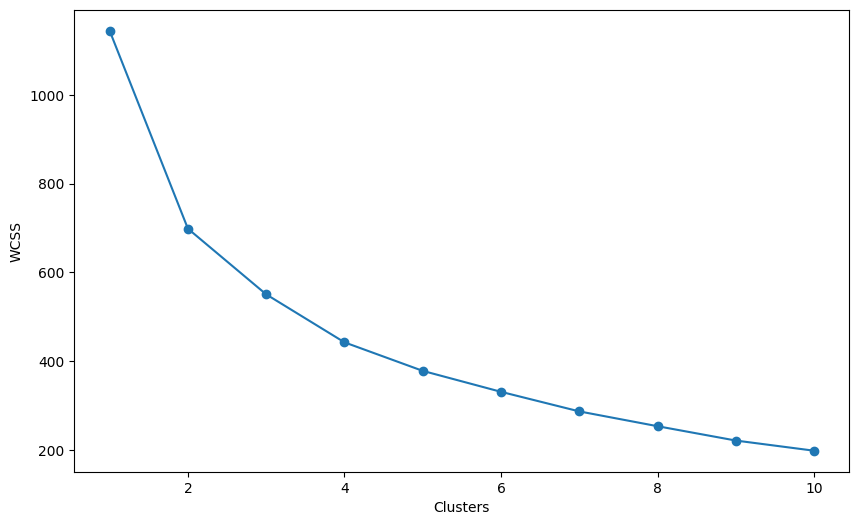

In [15]:
wcss = []

for i in range(1,11):

    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(pca_df)

    wcss.append(
        kmeans.inertia_
    )

plt.figure(figsize=(10,6))

plt.plot(
    range(1,11),
    wcss,
    marker='o'
)

plt.xlabel("Clusters")
plt.ylabel("WCSS")

plt.show()

# KMeans

In [16]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(
    pca_df
)

pca_df['Cluster'] = clusters
print(clusters)

[0 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 0 1 0 1 0 1 1 1 0 0 0 0 1 1 0 0 1 1 1 0
 0 0 1 0 1 1 1 1 1 1 0 1 0 0 1 0 1 1 0 0 1 1 0 1 1 0 0 0 0 0 1 1 0 0 1 0 1
 1 1 1 1 1 1 0 0 1 0 0 1 1 0 0 1 1 2 1 0 0 1 1 0 2 0 1 1 1 0 1 1 0 0 0 0 1
 1 0 0 1 1 0 1 1 1 0 1 1 1 1 1 0 0 1 0 1 1 0 2 1 1 0 0 1 1 0 1 0 1 1 1 0 0
 1 0 0 0 1 1 0 0 1 1 1 1 1 0 0 0 1 0 0]


# Silhouette Score

In [17]:
score = silhouette_score(
    pca_df[['PC1','PC2','PC3']],
    clusters
)

print(score)

0.3724161232764184


# KMeans Visualization

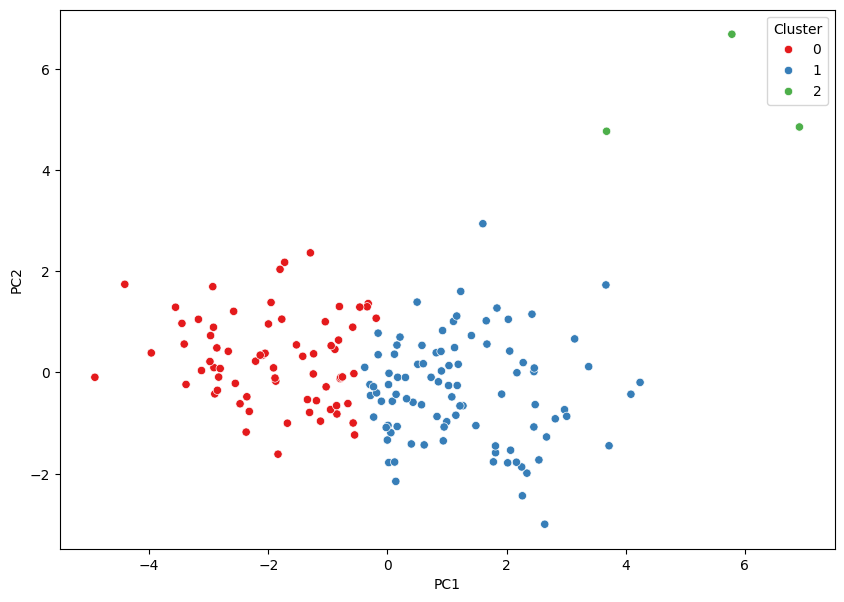

In [18]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=pca_df,
    palette='Set1'
)

plt.show()

# Add Country Names

In [19]:
result = pd.concat(
    [countries, pca_df],
    axis=1
)

result.head()

,country,PC1,PC2,PC3,Cluster
0,Afghanistan,-2.913025,0.095621,-0.718118,0
1,Albania,0.429911,-0.588156,-0.333486,1
2,Algeria,-0.285225,-0.455174,1.221505,1
3,Angola,-2.932423,1.695555,1.525044,0
4,Antigua and Barbuda,1.033576,0.136659,-0.225721,1


# DBSCAN

In [20]:
dbscan = DBSCAN(
    eps=0.7,
    min_samples=5
)

db_labels = dbscan.fit_predict(
    pca_df[['PC1','PC2','PC3']]
)

pca_df['DBSCAN_Cluster'] = db_labels

# DBSCAN Visualization

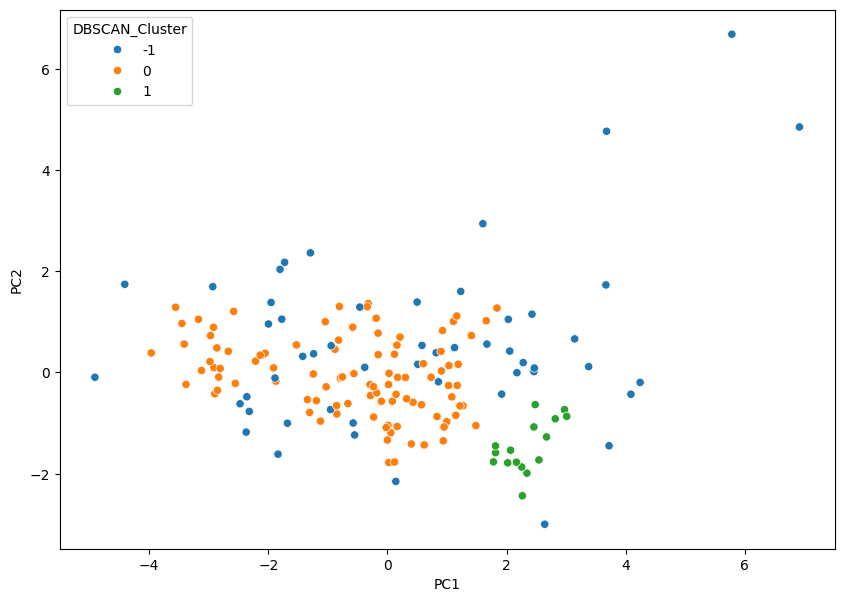

In [21]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='DBSCAN_Cluster',
    data=pca_df,
    palette='tab10'
)

plt.show()

# Country Recommendation


In [22]:
result['Cluster'] = clusters

cluster_summary = result.groupby(
    'Cluster'
).mean(numeric_only=True)

print(cluster_summary)

              PC1       PC2       PC3
Cluster                              
0       -1.901334  0.263055  0.053187
1        1.241625 -0.369269 -0.046362
2        5.460225  5.432473  0.211648


## Countries Needing Aid


In [23]:
result[
    result['Cluster']==0
]['country']

0      Afghanistan
3           Angola
12      Bangladesh
17           Benin
19         Bolivia
          ...     
161     Uzbekistan
162        Vanuatu
163      Venezuela
165          Yemen
166         Zambia
Name: country, Length: 70, dtype: object

---
## Conclusion

✅ Applied feature scaling and PCA for dimensionality reduction

✅ Built country segments using K-Means and DBSCAN

✅ Identified groups of countries with similar development characteristics

✅ Generated insights to support strategic aid allocation decisions

**Developed a data-driven Country Development Intelligence System**
---